# iAmTime forecasting usage

This notebook demonstrates four forecasting workflows with `iAmTimePipeline`:

1. Univariate forecasting
2. Multivariate forecasting
3. Forecasting with known exogenous variables
4. Forecasting with in-context examples

All examples load the public [`anishsaha/iAmTime-base-forecast`](https://huggingface.co/anishsaha/iAmTime-base-forecast) checkpoint from the Hugging Face Hub. The examples use synthetic data so they are reproducible and make the extra information in each richer input easy to inspect.

## Setup

Install the package and notebook dependencies from the repository root before running this notebook:

```bash
pip install -e ".[notebook]"
```

The first model load downloads the forecasting checkpoint from the Hugging Face Hub and caches it locally.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from iAmTime.pipeline import iAmTimePipeline

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=3, suppress=True)

In [ ]:
if torch.cuda.is_available():
    DEVICE = "cuda"
    TORCH_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float32
else:
    DEVICE = "cpu"
    TORCH_DTYPE = torch.float32

MODEL_ID = "anishsaha/iAmTime-base-forecast"

print(f"Device: {DEVICE}")
print(f"Dtype: {TORCH_DTYPE}")
print(f"Model: {MODEL_ID}")

Device: cuda
Dtype: torch.float32
Model: anishsaha/iAmTime-base-forecast


In [3]:
pipeline = iAmTimePipeline.from_pretrained(
    MODEL_ID,
    device_map=DEVICE,
    torch_dtype=TORCH_DTYPE,
)
pipeline.model.eval()
print("Pipeline loaded successfully.")

Pipeline loaded successfully.


### Forecast output

`predict_quantiles` returns quantiles with shape `(batch, horizon, quantiles)` for univariate input and `(batch, variates, horizon, quantiles)` for uniform multivariate input. This notebook requests the 10th, 50th, and 90th percentiles.

In [6]:
QUANTILE_LEVELS = [0.1, 0.5, 0.9]
COLORS = {"history": "#3f4652", "truth": "#23836b", "forecast": "#8f5fa2"}

def predict(input_batch, horizon):
    quantiles, _ = pipeline.predict_quantiles(
        input_batch,
        prediction_length=horizon,
        quantile_levels=QUANTILE_LEVELS,
    )
    return quantiles.detach().cpu().numpy()

def plot_forecast(ax, history, truth, quantiles, title, history_points=96):
    history = np.asarray(history)
    truth = np.asarray(truth)
    start = max(0, len(history) - history_points)
    history_x = np.arange(start, len(history))
    future_x = np.arange(len(history), len(history) + len(truth))
    ax.plot(history_x, history[start:], color=COLORS["history"], lw=1.4, label="History")
    ax.plot(future_x, truth, color=COLORS["truth"], lw=1.5, label="Observed future")
    ax.fill_between(future_x, quantiles[:, 0], quantiles[:, 2], color=COLORS["forecast"], alpha=0.20, label="10-90% interval")
    ax.plot(future_x, quantiles[:, 1], color=COLORS["forecast"], lw=1.8, label="Median forecast")
    ax.axvline(len(history) - 0.5, color="#999999", lw=0.8, ls="--")
    ax.set_title(title)
    ax.set_xlabel("Time step")
    ax.set_ylabel("Value")

## 1. Univariate forecasting

The simplest input is a two-dimensional array with shape `(batch, history)`. A list of one-dimensional arrays is also supported when histories have different lengths.

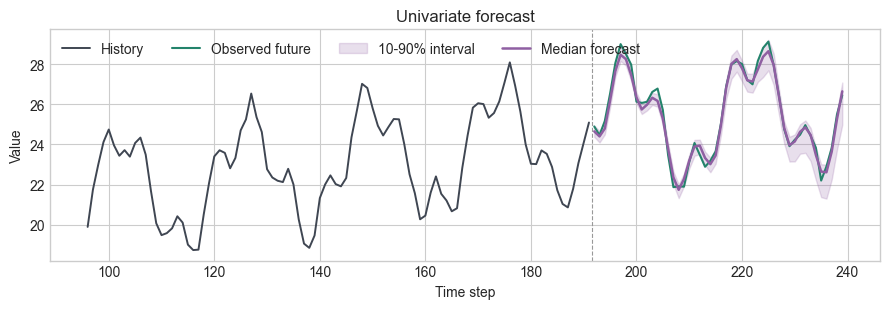

In [7]:
rng = np.random.default_rng(7)
HISTORY = 192
HORIZON = 48
t = np.arange(HISTORY + HORIZON)
univariate_series = (
    18.0
    + 0.035 * t
    + 2.8 * np.sin(2 * np.pi * t / 24)
    + 1.2 * np.sin(2 * np.pi * t / 7 + 0.5)
    + rng.normal(0, 0.25, len(t))
).astype(np.float32)

uni_history = univariate_series[:HISTORY]
uni_truth = univariate_series[HISTORY:]
uni_input = uni_history[None, :]  # (batch=1, history)
uni_quantiles = predict(uni_input, HORIZON)[0]

fig, ax = plt.subplots(figsize=(9, 3.2))
plot_forecast(ax, uni_history, uni_truth, uni_quantiles, "Univariate forecast")
ax.legend(ncol=4, frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

## 2. Multivariate forecasting

A multivariate target has shape `(batch, variates, history)`. iAmTime forecasts every variate and uses the histories of the other variates as additional context. Here, demand, orders, and site traffic share daily and weekly structure, so their joint history is informative.

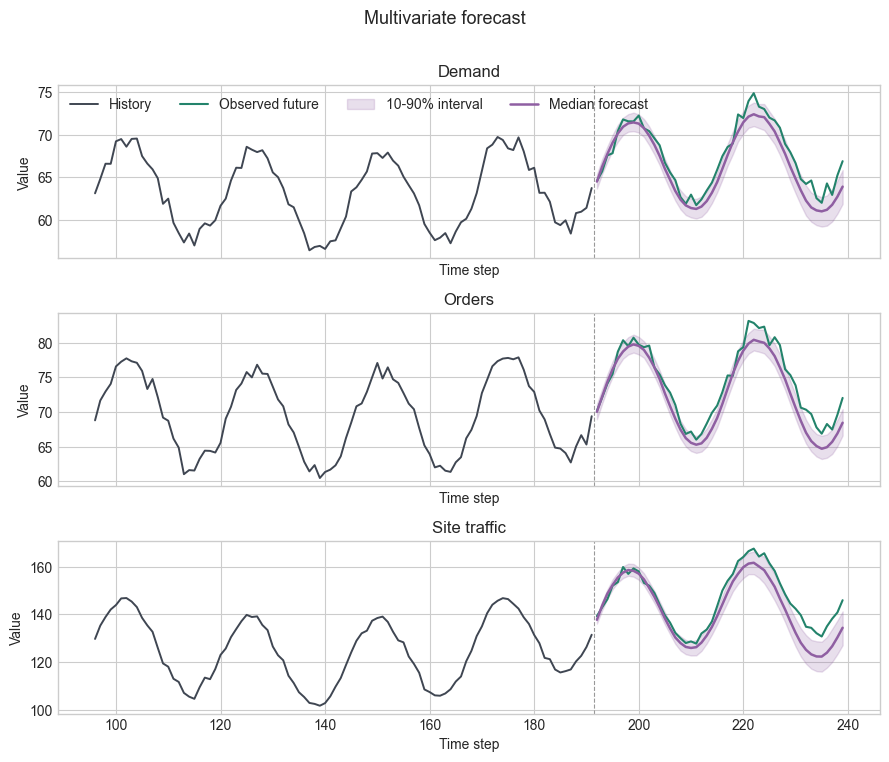

In [8]:
rng = np.random.default_rng(11)
t = np.arange(HISTORY + HORIZON)
daily = np.sin(2 * np.pi * t / 24)
weekly = np.sin(2 * np.pi * t / (24 * 7) - 0.7)
traffic = 120 + 18 * daily + 12 * weekly + 0.08 * t + rng.normal(0, 1.2, len(t))
orders = 42 + 0.22 * traffic + 4 * np.roll(daily, 2) + rng.normal(0, 0.7, len(t))
demand = 15 + 0.55 * orders + 0.08 * traffic + rng.normal(0, 0.45, len(t))
multi_series = np.stack([demand, orders, traffic]).astype(np.float32)
multi_history = multi_series[:, :HISTORY]
multi_truth = multi_series[:, HISTORY:]
multi_input = multi_history[None, :, :]  # (batch=1, variates=3, history)
multi_quantiles = predict(multi_input, HORIZON)[0]

fig, axes = plt.subplots(3, 1, figsize=(9, 7.5), sharex=True)
for index, (ax, name) in enumerate(zip(axes, ["Demand", "Orders", "Site traffic"])):
    plot_forecast(ax, multi_history[index], multi_truth[index], multi_quantiles[index], name)
axes[0].legend(ncol=4, frameon=False, loc="upper left")
fig.suptitle("Multivariate forecast", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 3. Forecasting with exogenous variables

Use the target-and-covariates dictionary when external drivers are available. Past covariates must align with the target history. Future covariates contain values known across the forecast horizon, such as calendar features, planned promotions, prices, or weather forecasts.

This example makes temperature, weekend status, and a planned promotion directly relevant to demand. The future promotion is intentionally placed only in the forecast window, demonstrating information that target history alone cannot provide.

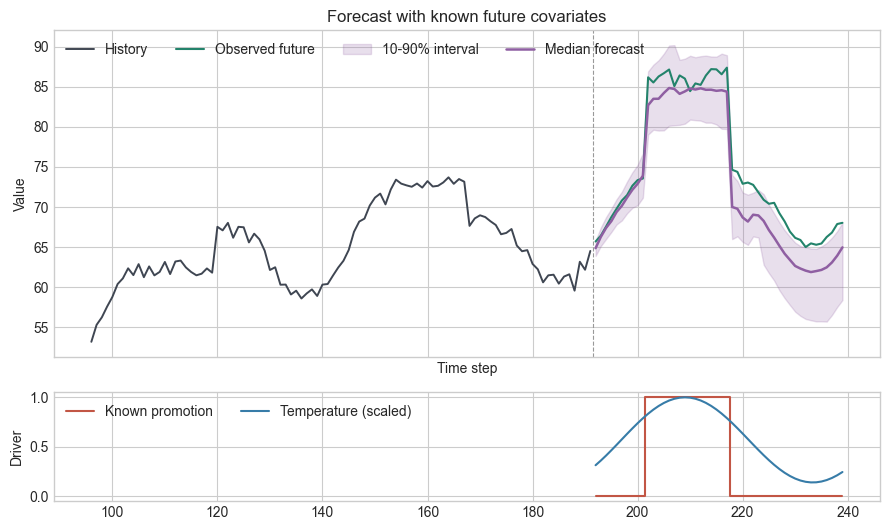

In [9]:
rng = np.random.default_rng(19)
t = np.arange(HISTORY + HORIZON)
temperature = 18 + 7 * np.sin(2 * np.pi * (t - 5) / 48) + 1.5 * np.sin(2 * np.pi * t / (24 * 7))
weekend = ((t // 24) % 7 >= 5).astype(np.float32)
promotion = np.zeros_like(t, dtype=np.float32)
promotion[HISTORY + 10:HISTORY + 26] = 1.0
promotion[48:62] = 1.0  # One historical promotion teaches its effect.
exog_target = (
    35
    + 0.10 * t
    + 0.75 * temperature
    + 5.0 * weekend
    + 12.0 * promotion
    + 2.0 * np.sin(2 * np.pi * t / 24)
    + rng.normal(0, 0.7, len(t))
).astype(np.float32)

exog_input = [{
    "target": exog_target[:HISTORY],
    "past_covariates": {
        "temperature": temperature[:HISTORY].astype(np.float32),
        "weekend": weekend[:HISTORY],
        "promotion": promotion[:HISTORY],
    },
    "future_covariates": {
        "temperature": temperature[HISTORY:].astype(np.float32),
        "weekend": weekend[HISTORY:],
        "promotion": promotion[HISTORY:],
    },
}]
exog_quantiles = predict(exog_input, HORIZON)[0]

fig, (ax, driver_ax) = plt.subplots(2, 1, figsize=(9, 5.4), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
plot_forecast(ax, exog_target[:HISTORY], exog_target[HISTORY:], exog_quantiles, "Forecast with known future covariates")
ax.legend(ncol=4, frameon=False, loc="upper left")
future_x = np.arange(HISTORY, HISTORY + HORIZON)
driver_ax.step(future_x, promotion[HISTORY:], where="mid", color="#c25645", label="Known promotion")
driver_ax.plot(future_x, (temperature[HISTORY:] - temperature.min()) / np.ptp(temperature), color="#377ca8", label="Temperature (scaled)")
driver_ax.set_ylabel("Driver")
driver_ax.legend(ncol=2, frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

## 4. Forecasting with examples

The full ICL format supplies completed support examples before the query. Each example contains a target history and its observed future; optional exogenous histories and futures can accompany both examples and the query.

The supports below share the query's driver-to-target relationship and horizon. The query's true future is kept out of the model input and used only for plotting.

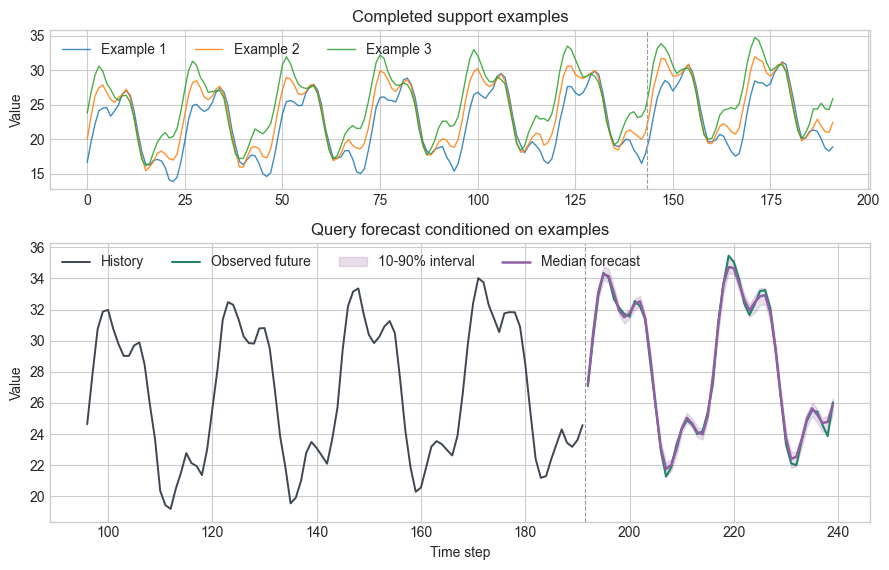

In [10]:
EXAMPLE_HISTORY = 144
NUM_EXAMPLES = 3

def make_example(seed, phase, level, history_length=EXAMPLE_HISTORY, horizon=HORIZON):
    rng = np.random.default_rng(seed)
    t = np.arange(history_length + horizon)
    driver = np.sin(2 * np.pi * t / 24 + phase) + 0.45 * np.sin(2 * np.pi * t / 8 - 0.3)
    target = level + 0.025 * t + 4.8 * driver + 1.2 * np.roll(driver, 2) + rng.normal(0, 0.22, len(t))
    return target.astype(np.float32), driver.astype(np.float32)

support_series = [make_example(30 + i, phase, 20 + 1.5 * i) for i, phase in enumerate([-0.35, 0.05, 0.4])]
query_target, query_driver = make_example(44, 0.18, 23.0, history_length=HISTORY)

example_input = [{
    "example_target_histories": [target[:EXAMPLE_HISTORY] for target, _ in support_series],
    "example_target_futures": [target[EXAMPLE_HISTORY:] for target, _ in support_series],
    "example_exog_histories": [driver[None, :EXAMPLE_HISTORY] for _, driver in support_series],
    "example_exog_futures": [driver[None, EXAMPLE_HISTORY:] for _, driver in support_series],
    "query_target_history": query_target[:HISTORY],
    "query_exog_history": query_driver[None, :HISTORY],
    "query_exog_future": query_driver[None, HISTORY:],
}]
example_quantiles = predict(example_input, HORIZON)[0]

fig, axes = plt.subplots(2, 1, figsize=(9, 5.8), gridspec_kw={"height_ratios": [1.25, 2.2]})
for index, (target, _) in enumerate(support_series):
    x = np.arange(len(target))
    axes[0].plot(x, target, lw=1.0, alpha=0.85, label=f"Example {index + 1}")
axes[0].axvline(EXAMPLE_HISTORY - 0.5, color="#999999", lw=0.8, ls="--")
axes[0].set_title("Completed support examples")
axes[0].set_ylabel("Value")
axes[0].legend(ncol=3, frameon=False, loc="upper left")
plot_forecast(axes[1], query_target[:HISTORY], query_target[HISTORY:], example_quantiles, "Query forecast conditioned on examples")
axes[1].legend(ncol=4, frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

## Supported forecasting inputs

The four sections cover the most useful interfaces. The pipeline also accepts:

- A 2-D NumPy array or PyTorch tensor: `(batch, history)`.
- A list of 1-D arrays/tensors for variable-length univariate histories.
- A 3-D array/tensor: `(batch, variates, history)`.
- A list of 2-D arrays for variable-size or variable-length multivariate histories.
- A list of `{target, past_covariates, future_covariates}` dictionaries. Covariate dictionaries are optional; future covariates may differ from past covariates and missing counterparts are internally represented as unavailable values.
- A list of full ICL dictionaries with example target histories/futures, optional example covariates, and query history/covariates. Example lengths and exogenous counts may vary.

For forecasting, do not include the query's observed target future in inference input. Specify `prediction_length`, or let the pipeline infer it from a non-empty query/future-covariate horizon.

## Checkpoint scope

This notebook uses the publicly available forecasting checkpoint. iAmTime also supports imputation, anomaly detection, and classification, but checkpoints for those tasks are not currently published.